# MISO Energy Hub — Day-Ahead LMP Forecasting

Fine-tuning **Amazon Chronos-2** with LoRA on MISO (Midcontinent ISO) hourly day-ahead locational marginal price (LMP) data for three pricing hubs, using a seasonal blocked cross-validation strategy to prevent temporal leakage.

| Attribute | Detail |
|-----------|--------|
| **Model** | `amazon/chronos-2` + LoRA (rank 8) |
| **Data** | Hourly DA LMP · 2019-09 → 2021-08 · 3 hubs |
| **Hubs** | AECI (0) · Michigan Hub (1) · Minnesota Hub (2) |
| **Covariates** | MISO MTLF load forecasts · regional wind speed · dew-point temperature · calendar features |
| **CV strategy** | 6-fold seasonal blocked CV · best fold by validation NLL |
| **Forecast horizon** | 24 h |
| **Metrics** | MAE, WAPE |

---

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import glob
import joblib
from dataclasses import dataclass
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler

from chronos import BaseChronosPipeline

from transformers import EarlyStoppingCallback

import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading

Load the pre-processed parquet file containing hourly MISO features and day-ahead LMP targets covering 2019-09 → 2021-08.

In [2]:
raw_df = pd.read_parquet("data/model_ready.parquet", engine="fastparquet")
raw_df.head()

,central_mtlf_fc,north_mtlf_fc,south_mtlf_fc,system_mtlf_fc,ia_ksux_ws_mph_fc,il_kmdw_ws_mph_fc,il_kord_ws_mph_fc,mi_kanj_ws_mph_fc,mi_karb_ws_mph_fc,mi_kazo_ws_mph_fc,...,mi_klan_td_f_fc,mn_kinl_td_f_fc,mn_kpqn_td_f_fc,mo_ksgf_td_f_fc,mo_kstl_td_f_fc,oh_kluk_td_f_fc,ok_klaw_td_f_fc,da_energy_aeci_lmpexpost_ac,da_energy_michigan_hub_lmpexpost_ac,da_energy_minn_hub_lmpexpost_ac
interval_ending_dt_utc,,,,,,,,,,,,,,,,,,,,,
2021-07-31 01:00:00,44380.0,20398.0,28946.0,93724.0,4.023245,4.470273,4.470273,3.129191,2.682164,2.682164,...,11.111111,12.777778,17.777778,21.666667,20.0,16.111111,17.777778,37.62,38.13,42.86
2021-07-31 02:00:00,42821.0,19659.0,27916.0,90396.0,4.157354,4.023245,3.889137,2.548055,2.101028,2.235136,...,11.111111,13.333333,17.222222,21.833333,20.0,16.277778,18.333333,36.32,35.76,39.28
2021-07-31 03:00:00,40950.0,19112.0,26880.0,86942.0,4.336165,3.576218,3.263299,1.922217,1.475190,1.788109,...,11.111111,13.888889,16.666667,22.055556,20.0,16.500000,18.888889,32.86,32.51,34.54
2021-07-31 04:00:00,38229.0,18106.0,25453.0,81788.0,4.470273,3.129191,2.682164,1.341082,0.894055,1.341082,...,11.111111,14.444444,16.111111,22.222222,20.0,16.666667,19.444444,29.01,29.46,33.05
2021-07-31 05:00:00,36287.0,16900.0,23928.0,77115.0,4.023245,2.235136,1.922217,1.341082,0.581135,1.028163,...,11.111111,13.888889,15.944444,22.055556,20.0,16.500000,19.611111,28.20,30.35,28.58


In [3]:
raw_df.shape

(17497, 41)

## 2. Feature Engineering

Reshape from wide format (one row per timestamp, three target columns) to a **long panel** where each pricing hub is an independent time series. Calendar features are added as sine/cosine encodings to give the model smooth, boundary-free representations of hour-of-day and day-of-year seasonality.

| Hub ID | Hub Name | Source column |
|--------|----------|---------------|
| 0 | AECI | `da_energy_aeci_lmpexpost_ac` |
| 1 | Michigan Hub | `da_energy_michigan_hub_lmpexpost_ac` |
| 2 | Minnesota Hub | `da_energy_minn_hub_lmpexpost_ac` |

In [4]:
# Define the target columns
targets = [
    "da_energy_aeci_lmpexpost_ac",
    "da_energy_michigan_hub_lmpexpost_ac",
    "da_energy_minn_hub_lmpexpost_ac"
]

# Create a mapping from target column names to hub IDs
hub_mapping = {
    "da_energy_aeci_lmpexpost_ac": 0,
    "da_energy_michigan_hub_lmpexpost_ac": 1,
    "da_energy_minn_hub_lmpexpost_ac": 2
}

# Get all the original feature columns (excluding the targets)
feature_columns = [col for col in raw_df.columns if col not in targets]

# Convert the index to datetime if it's not already
if not pd.api.types.is_datetime64_any_dtype(raw_df.index):
    raw_df.index = pd.to_datetime(raw_df.index, utc=True)

# Create the formatted dataframe
formatted_df = pd.DataFrame()

for target in targets:
    # Create a copy for this target
    temp_df = raw_df.copy()
    
    # Create datetime_utc column (just the date part) from the index as string
    idx = temp_df.index
    temp_df['datetime_utc'] = idx.tz_convert(None) if idx.tz is not None else idx
    
    # Create hub column (analog to hub)
    temp_df['hub'] = hub_mapping[target]
    
    # Create target column with the target values
    temp_df['target'] = temp_df[target]
    
    # Create is_weekend column (0 = weekday, 1 = weekend)
    temp_df['is_weekend'] = (temp_df.index.dayofweek >= 5).astype(int)
    
    # Create time-of-hour sine/cosine features
    hour = temp_df.index.hour
    temp_df['sin_hod'] = np.sin(2 * np.pi * hour / 24)
    temp_df['cos_hod'] = np.cos(2 * np.pi * hour / 24)
    
    # Create day-of-year sine/cosine features
    day_of_year = temp_df.index.dayofyear
    temp_df['sin_doy'] = np.sin(2 * np.pi * day_of_year / 365)
    temp_df['cos_doy'] = np.cos(2 * np.pi * day_of_year / 365)
    
    # Select: datetime_utc, hub, target, is_weekend, time features, PLUS all original features
    columns_to_keep = ['datetime_utc', 'hub', 'target', 'is_weekend', 
                       'sin_hod', 'cos_hod', 'sin_doy', 'cos_doy'] + feature_columns
    temp_df = temp_df[columns_to_keep]
    
    # Reset index for this subset
    temp_df = temp_df.reset_index(drop=True)
    
    # Append to formatted_df
    formatted_df = pd.concat([formatted_df, temp_df], ignore_index=True)

# Reset final index
formatted_df = formatted_df.reset_index(drop=True)


print(f"\nTotal rows: {len(formatted_df)}")
print(f"Columns: {formatted_df.columns.tolist()}")

display(formatted_df.head())
display(formatted_df.tail())


Total rows: 52491
Columns: ['datetime_utc', 'hub', 'target', 'is_weekend', 'sin_hod', 'cos_hod', 'sin_doy', 'cos_doy', 'central_mtlf_fc', 'north_mtlf_fc', 'south_mtlf_fc', 'system_mtlf_fc', 'ia_ksux_ws_mph_fc', 'il_kmdw_ws_mph_fc', 'il_kord_ws_mph_fc', 'mi_kanj_ws_mph_fc', 'mi_karb_ws_mph_fc', 'mi_kazo_ws_mph_fc', 'mi_klan_ws_mph_fc', 'mn_kinl_ws_mph_fc', 'mn_krst_ws_mph_fc', 'mo_kstl_ws_mph_fc', 'oh_kakr_ws_mph_fc', 'ok_kclk_ws_mph_fc', 'ok_kokc_ws_mph_fc', 'ok_ktul_ws_mph_fc', 'ok_kwdg_ws_mph_fc', 'sc_kchs_ws_mph_fc', 'ar_kjbr_td_f_fc', 'ia_kdsm_td_f_fc', 'ia_ksux_td_f_fc', 'in_kfwa_td_f_fc', 'in_kind_td_f_fc', 'in_klaf_td_f_fc', 'in_ksbn_td_f_fc', 'ky_ksdf_td_f_fc', 'la_kbtr_td_f_fc', 'la_klch_td_f_fc', 'la_kshv_td_f_fc', 'mi_klan_td_f_fc', 'mn_kinl_td_f_fc', 'mn_kpqn_td_f_fc', 'mo_ksgf_td_f_fc', 'mo_kstl_td_f_fc', 'oh_kluk_td_f_fc', 'ok_klaw_td_f_fc']


,datetime_utc,hub,target,is_weekend,sin_hod,cos_hod,sin_doy,cos_doy,central_mtlf_fc,north_mtlf_fc,...,la_kbtr_td_f_fc,la_klch_td_f_fc,la_kshv_td_f_fc,mi_klan_td_f_fc,mn_kinl_td_f_fc,mn_kpqn_td_f_fc,mo_ksgf_td_f_fc,mo_kstl_td_f_fc,oh_kluk_td_f_fc,ok_klaw_td_f_fc
0,2021-07-31 01:00:00,0,37.62,1,0.258819,0.965926,-0.486273,-0.873807,44380.0,20398.0,...,24.444444,23.333333,21.111111,11.111111,12.777778,17.777778,21.666667,20.0,16.111111,17.777778
1,2021-07-31 02:00:00,0,36.32,1,0.500000,0.866025,-0.486273,-0.873807,42821.0,19659.0,...,24.611111,23.722222,21.666667,11.111111,13.333333,17.222222,21.833333,20.0,16.277778,18.333333
2,2021-07-31 03:00:00,0,32.86,1,0.707107,0.707107,-0.486273,-0.873807,40950.0,19112.0,...,24.833333,24.055556,22.222222,11.111111,13.888889,16.666667,22.055556,20.0,16.500000,18.888889
3,2021-07-31 04:00:00,0,29.01,1,0.866025,0.500000,-0.486273,-0.873807,38229.0,18106.0,...,25.000000,24.444444,22.777778,11.111111,14.444444,16.111111,22.222222,20.0,16.666667,19.444444
4,2021-07-31 05:00:00,0,28.20,1,0.965926,0.258819,-0.486273,-0.873807,36287.0,16900.0,...,24.833333,24.444444,22.944444,11.111111,13.888889,15.944444,22.055556,20.0,16.500000,19.611111


,datetime_utc,hub,target,is_weekend,sin_hod,cos_hod,sin_doy,cos_doy,central_mtlf_fc,north_mtlf_fc,...,la_kbtr_td_f_fc,la_klch_td_f_fc,la_kshv_td_f_fc,mi_klan_td_f_fc,mn_kinl_td_f_fc,mn_kpqn_td_f_fc,mo_ksgf_td_f_fc,mo_kstl_td_f_fc,oh_kluk_td_f_fc,ok_klaw_td_f_fc
52486,2021-07-30 20:00:00,2,55.51,0,-0.866025,0.500000,-0.471160,-0.882048,48950.0,21120.0,...,23.722222,23.333333,22.388889,9.277778,11.277778,16.277778,20.944444,18.888889,16.500000,18.722222
52487,2021-07-30 21:00:00,2,54.82,0,-0.707107,0.707107,-0.471160,-0.882048,49200.0,21350.0,...,23.500000,23.333333,22.055556,9.055556,11.500000,16.500000,20.722222,18.888889,16.277778,18.500000
52488,2021-07-30 22:00:00,2,56.44,0,-0.500000,0.866025,-0.471160,-0.882048,49210.0,21520.0,...,23.333333,23.333333,21.666667,8.888889,11.666667,16.666667,20.555556,18.888889,16.111111,18.333333
52489,2021-07-30 23:00:00,2,52.06,0,-0.258819,0.965926,-0.471160,-0.882048,48520.0,21530.0,...,23.333333,23.333333,21.666667,9.055556,12.222222,17.055556,20.722222,18.888889,16.111111,18.166667
52490,2021-07-31 00:00:00,2,46.88,1,0.000000,1.000000,-0.486273,-0.873807,46870.0,21210.0,...,23.333333,23.333333,21.666667,9.277778,12.777778,17.388889,20.944444,18.888889,16.111111,17.944444


In [5]:
formatted_df.shape

(52491, 46)

## 3. Exploratory Analysis

Quick sanity-checks on the reshaped panel: target price distribution per hub and the overall time-series span.

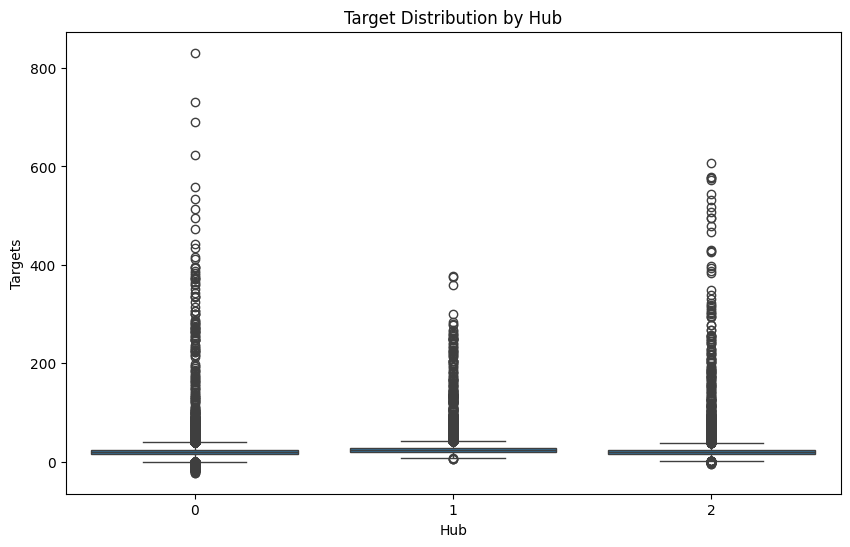

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=formatted_df, x="hub", y="target")
plt.title("Target Distribution by Hub")
plt.xlabel("Hub")
plt.ylabel("Targets")
plt.show()

In [7]:
earliest_date = formatted_df['datetime_utc'].min()
latest_date = formatted_df['datetime_utc'].max()

print(f"Earliest date: {earliest_date}")
print(f"Latest date: {latest_date}")

Earliest date: 2019-09-01 00:00:00
Latest date: 2021-08-30 00:00:00


In [8]:
formatted_df = formatted_df.sort_values("datetime_utc").reset_index(drop=True)
display(formatted_df.head())

,datetime_utc,hub,target,is_weekend,sin_hod,cos_hod,sin_doy,cos_doy,central_mtlf_fc,north_mtlf_fc,...,la_kbtr_td_f_fc,la_klch_td_f_fc,la_kshv_td_f_fc,mi_klan_td_f_fc,mn_kinl_td_f_fc,mn_kpqn_td_f_fc,mo_ksgf_td_f_fc,mo_kstl_td_f_fc,oh_kluk_td_f_fc,ok_klaw_td_f_fc
0,2019-09-01 00:00:00,1,24.80,1,0.000000,1.000000,-0.871706,-0.490029,39290.0,16050.0,...,20.166667,22.611111,20.555556,10.944444,10.166667,13.722222,20.944444,19.277778,19.277778,21.111111
1,2019-09-01 00:00:00,2,22.15,1,0.000000,1.000000,-0.871706,-0.490029,39290.0,16050.0,...,20.166667,22.611111,20.555556,10.944444,10.166667,13.722222,20.944444,19.277778,19.277778,21.111111
2,2019-09-01 00:00:00,0,21.95,1,0.000000,1.000000,-0.871706,-0.490029,39290.0,16050.0,...,20.166667,22.611111,20.555556,10.944444,10.166667,13.722222,20.944444,19.277778,19.277778,21.111111
3,2019-09-01 01:00:00,2,21.05,1,0.258819,0.965926,-0.871706,-0.490029,39644.0,15757.0,...,20.555556,22.777778,21.111111,9.444444,10.555556,14.444444,19.444444,19.444444,17.777778,21.111111
4,2019-09-01 01:00:00,0,20.77,1,0.258819,0.965926,-0.871706,-0.490029,39644.0,15757.0,...,20.555556,22.777778,21.111111,9.444444,10.555556,14.444444,19.444444,19.444444,17.777778,21.111111


## 4. Data Quality Check

Verify completeness of the hourly panel for each hub before entering the CV pipeline.

In [9]:
# Check if any expected time steps are missing (assuming hourly data as an example)
for hub, grp in formatted_df.groupby("hub"):
    expected_range = pd.date_range(start=grp["datetime_utc"].min(), end=grp["datetime_utc"].max(), freq="D") 
    missing = len(expected_range) - len(grp)
    if missing > 0:
        print(f"Hub {hub} is missing {missing} timestamps!")
    else:
        print("No missing entries")

No missing entries
No missing entries
No missing entries


## 5. Cross-Validation Design

We use **seasonal blocked cross-validation** to respect temporal ordering and avoid look-ahead leakage. Six non-overlapping quarterly validation windows span the full 2019-09 → 2021-04 training period; the April–August 2021 block is held out as the final test set and is never touched during CV.

```
 Training data (2019-09 → 2021-04)                  │ Test (held out)
 ┌────────────────────────────────────────────────┐ │ ┌────────────┐
 │ fold 1 : train ··············│ Q4-2019 (val)   │ │ │            │
 │ fold 2 : train ··············│ Q1-2020 (val)   │ │ │  Apr–Aug   │
 │ fold 3 : train ··············│ Q2-2020 (val)   │ │ │   2021     │
 │ fold 4 : train ··············│ Q3-2020 (val)   │ │ │            │
 │ fold 5 : train ··············│ Q4-2020 (val)   │ │ │            │
 │ fold 6 : train ··············│ Q1-2021 (val)   │ │ │            │
 └────────────────────────────────────────────────┘ │ └────────────┘
```

Each fold fine-tunes a **fresh** copy of Chronos-2 to keep folds independent; the best model is selected by minimum validation NLL.

In [ ]:
# CV constants
TRAIN_START = pd.Timestamp("2019-09-01")
TRAIN_END   = pd.Timestamp("2021-04-01")
TEST_START  = pd.Timestamp("2021-04-01")
TEST_END    = pd.Timestamp("2021-08-30")

# ----------------------------------------------------------------------------
# CV Fold definitions
# ----------------------------------------------------------------------------

@dataclass(frozen=True)
class CVFold:
    name      : str
    val_start : pd.Timestamp
    val_end   : pd.Timestamp   # exclusive

    def __post_init__(self):
        assert self.val_start < self.val_end, f"{self.name}: empty validation window"
        assert self.val_end <= TEST_START, f"{self.name}: validation bleeds into test period"

    @property
    def n_val_days(self) -> int:
        return (self.val_end - self.val_start).days

    @property
    def n_train_days(self) -> int:
        return (TEST_START - TRAIN_START).days - self.n_val_days


CV_FOLDS: list[CVFold] = [
    CVFold("Q4_2019", pd.Timestamp("2019-10-01"), pd.Timestamp("2020-01-01")),
    CVFold("Q1_2020", pd.Timestamp("2020-01-01"), pd.Timestamp("2020-04-01")),
    CVFold("Q2_2020", pd.Timestamp("2020-04-01"), pd.Timestamp("2020-07-01")),
    CVFold("Q3_2020", pd.Timestamp("2020-07-01"), pd.Timestamp("2020-10-01")),
    CVFold("Q4_2020", pd.Timestamp("2020-10-01"), pd.Timestamp("2021-01-01")),
    CVFold("Q1_2021", pd.Timestamp("2021-01-01"), pd.Timestamp("2021-04-01")),
]

for fold in CV_FOLDS:
    print(f"{fold.name}  val={fold.n_val_days:,} days  "
          f"train(blocked)={fold.n_train_days:,} days")

## 6. Covariates & Model Hyperparameters

Define the full covariate set and training constants. `SCALE_COLS` lists the continuous features that will be standardised with `RobustScaler`; calendar columns are already bounded and are excluded from scaling.

In [ ]:
# All future covariates (weather + MTLF + calendar features)
COVARIATE_COLS = [
    # MTLF load forecasts
    "central_mtlf_fc", "north_mtlf_fc", "south_mtlf_fc", "system_mtlf_fc",

    # Wind speed forecasts (mph)
    "ia_ksux_ws_mph_fc", "il_kmdw_ws_mph_fc", "il_kord_ws_mph_fc",
    "mi_kanj_ws_mph_fc", "mi_karb_ws_mph_fc", "mi_kazo_ws_mph_fc",
    "mi_klan_ws_mph_fc", "mn_kinl_ws_mph_fc", "mn_krst_ws_mph_fc",
    "mo_kstl_ws_mph_fc", "oh_kakr_ws_mph_fc", "ok_kclk_ws_mph_fc",
    "ok_kokc_ws_mph_fc", "ok_ktul_ws_mph_fc", "ok_kwdg_ws_mph_fc",
    "sc_kchs_ws_mph_fc",

    # Dew-point temperature forecasts (°F)
    "ar_kjbr_td_f_fc", "ia_kdsm_td_f_fc", "ia_ksux_td_f_fc",
    "in_kfwa_td_f_fc", "in_kind_td_f_fc", "in_klaf_td_f_fc",
    "in_ksbn_td_f_fc", "ky_ksdf_td_f_fc", "la_kbtr_td_f_fc",
    "la_klch_td_f_fc", "la_kshv_td_f_fc", "mi_klan_td_f_fc",
    "mn_kinl_td_f_fc", "mn_kpqn_td_f_fc", "mo_ksgf_td_f_fc",
    "mo_kstl_td_f_fc", "oh_kluk_td_f_fc", "ok_klaw_td_f_fc",

    # Calendar features
    "is_weekend", "sin_hod", "cos_hod", "sin_doy", "cos_doy",
]

CALENDAR_COLS = ["is_weekend", "sin_hod", "cos_hod", "sin_doy", "cos_doy"]
SCALE_COLS    = [c for c in COVARIATE_COLS if c not in CALENDAR_COLS]

TARGET_COL     = "target"
LEARNING_RATE  = 2e-5
BATCH_SIZE     = 32
CONTEXT_LENGTH = 168   # 1 week of hourly data
HORIZON        = 24    # training prediction horizon
EVAL_HORIZON   = 24    # test evaluation horizon
STRIDE         = 24    # non-overlapping 24-hour windows
QUANTILES      = [0.1, 0.5, 0.9]
BASE_MODEL     = "amazon/chronos-2"
LORA_CONFIG    = {
    "r"             : 8,
    "lora_alpha"    : 16,
    "lora_dropout"  : 0.0,
    "target_modules": [
        "self_attention.q",
        "self_attention.k",
        "self_attention.v",
        "self_attention.o",
        "output_patch_embedding.output_layer",
    ],
}

## 7. Train / Test Split

Slice the panel **once**, before any CV. The global `full_scaler` is fit exclusively on the pre-test training window and then applied to the test set, ensuring zero leakage from test data into scaling statistics.

Artefacts (`full_scaler.joblib`, `test_df.parquet`) are persisted for session recovery without re-running the full CV.

In [ ]:
formatted_df["datetime_utc"] = pd.to_datetime(formatted_df["datetime_utc"])

train_hub = formatted_df[formatted_df["datetime_utc"] <  TEST_START].copy().reset_index(drop=True)
test_hub  = formatted_df[formatted_df["datetime_utc"] >= TEST_START].copy().reset_index(drop=True)

# Scaler fit on the full training period only — never touches the test set
full_scaler = RobustScaler()
full_scaler.fit(train_hub[SCALE_COLS])
test_hub[SCALE_COLS] = full_scaler.transform(test_hub[SCALE_COLS])

test_df = test_hub

# Persist artefacts for session recovery without re-running CV
joblib.dump(full_scaler, "full_scaler.joblib")
test_df.to_parquet("test_df.parquet", index=False)

print(f"train_hub : {train_hub['datetime_utc'].nunique():,} unique timestamps  ({len(train_hub):,} rows)")
print(f"test_df   : {test_df['datetime_utc'].nunique():,} unique timestamps  ({len(test_df):,} rows)")
print("Artefacts saved: full_scaler.joblib  |  test_df.parquet")

## 8. Helper Functions

### Data Preparation

- **`make_fold_splits`** — splits `train_hub` into `(train_df, val_df)` for a single CV fold, fits a fold-local `RobustScaler` on the training split only, and optionally saves it to disk.
- **`build_chronos_inputs`** — converts the long-format panel into the `list[dict]` structure expected by `Chronos2Pipeline.fit()`.

In [ ]:
def make_fold_splits(
    df         : pd.DataFrame,
    fold       : CVFold,
    scale_cols : list[str]  = SCALE_COLS,
    output_dir : str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, RobustScaler]:
    """
    Splits train_hub into (train_df, val_df) for one CV fold.
    Fits a RobustScaler on train_df only and applies it to both splits.
    Persists the fold scaler to output_dir if provided.
    """
    dt = df["datetime_utc"]
    is_val   = (dt >= fold.val_start) & (dt < fold.val_end)
    is_train = ~is_val

    train_df = df[is_train].copy().reset_index(drop=True)
    val_df   = df[is_val  ].copy().reset_index(drop=True)

    scaler = RobustScaler()
    scaler.fit(train_df[scale_cols])
    for subset in (train_df, val_df):
        subset[scale_cols] = scaler.transform(subset[scale_cols])

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        joblib.dump(scaler, os.path.join(output_dir, "scaler.joblib"))

    print(
        f"  [{fold.name}]  "
        f"train={train_df['datetime_utc'].nunique():,} timestamps  "
        f"val={val_df['datetime_utc'].nunique():,} timestamps"
    )
    return train_df, val_df, scaler


def build_chronos_inputs(
    df             : pd.DataFrame,
    covariate_cols : list[str] = COVARIATE_COLS,
) -> list[dict]:
    """
    Converts a long-format DataFrame into the list-of-dicts structure
    expected by the Chronos pipeline's fit() method.
    """
    inputs = []
    for _, hub_df in df.groupby("hub", sort=True):
        hub_df = hub_df.sort_values("datetime_utc")
        inputs.append({
            "target": hub_df[[TARGET_COL]].to_numpy(dtype="float32").T,
            "past_covariates": {
                col: hub_df[col].to_numpy(dtype="float32")
                for col in covariate_cols
            },
            "future_covariates": {col: None for col in covariate_cols},
        })
    return inputs

### Forecasting & Evaluation Utilities

- **`run_sliding_window_forecast`** — batches all three hubs into a single `predict_df` call per window (enabling `cross_learning`), then computes per-hub MAE and WAPE for every non-overlapping 24-hour window.
- **`evaluate_on_test`** — thin wrapper that runs the above on the held-out test set, deduplicates overlapping windows, and prints aggregate metrics.

In [ ]:
def run_sliding_window_forecast(
    test_df           : pd.DataFrame,
    model,
    context_length    : int,
    prediction_length : int,
    stride            : int,
    covariate_cols    : list[str],
    quantile_levels   : list[float] = QUANTILES,
) -> pd.DataFrame:
    """
    Non-overlapping sliding-window forecast over all hubs simultaneously.
    All hubs are batched in a single predict_df call per window so that
    cross_learning=True operates correctly.
    """
    required_cols = {"datetime_utc", "hub", TARGET_COL} | set(covariate_cols)
    missing = required_cols - set(test_df.columns)
    if missing:
        raise ValueError(f"test_df missing columns: {missing}")

    q_rename_map     = {str(q): f"q_{int(round(q * 100))}" for q in quantile_levels}
    renamed_q_cols   = list(q_rename_map.values())
    expected_q_cols  = list(q_rename_map.keys())
    median_col_final = "q_50"

    hub_dfs = {
        hub: grp.sort_values("datetime_utc").reset_index(drop=True)
        for hub, grp in test_df.groupby("hub", sort=True)
    }

    min_hub_len  = min(len(df) for df in hub_dfs.values())
    min_required = context_length + prediction_length
    if min_hub_len < min_required:
        raise ValueError(
            f"Shortest hub has {min_hub_len} rows, need ≥ {min_required}."
        )

    all_predictions: list[pd.DataFrame] = []
    n_windows = 0

    for i in range(0, min_hub_len - context_length - prediction_length + 1, stride):
        context_frames, future_frames, actuals_frames = [], [], []

        for hub, hub_df in hub_dfs.items():
            ctx = hub_df.iloc[i : i + context_length]
            fut = hub_df.iloc[i + context_length : i + context_length + prediction_length]
            context_frames.append(ctx[["datetime_utc", "hub", TARGET_COL] + covariate_cols])
            future_frames.append(fut[["datetime_utc", "hub"] + covariate_cols])
            actuals_frames.append(fut[["datetime_utc", "hub", TARGET_COL]])

        combined_context = pd.concat(context_frames, ignore_index=True)
        combined_future  = pd.concat(future_frames,  ignore_index=True)
        actuals          = pd.concat(actuals_frames,  ignore_index=True)

        pred = model.predict_df(
            combined_context,
            future_df         = combined_future,
            prediction_length = prediction_length,
            quantile_levels   = quantile_levels,
            cross_learning    = True,
            id_column         = "hub",
            timestamp_column  = "datetime_utc",
            target            = TARGET_COL,
        )

        missing_q = set(expected_q_cols) - set(pred.columns)
        if missing_q:
            raise AssertionError(
                f"Window {i}: quantile columns {missing_q} missing. "
                f"Available: {pred.columns.tolist()}"
            )
        pred = pred.rename(columns=q_rename_map)

        df_win = pred.merge(actuals, on=["datetime_utc", "hub"], how="inner")
        if len(df_win) != prediction_length * len(hub_dfs):
            raise ValueError(
                f"Window {i}: merged {len(df_win)} rows, "
                f"expected {prediction_length * len(hub_dfs)}."
            )

        df_win["predictions"] = df_win[median_col_final]
        df_win["target_name"] = TARGET_COL

        for hub, grp in df_win.groupby("hub"):
            residuals = (grp[TARGET_COL] - grp[median_col_final]).abs()
            denom     = grp[TARGET_COL].abs().sum()
            df_win.loc[grp.index, "MAE"]  = residuals.mean()
            df_win.loc[grp.index, "WAPE"] = residuals.sum() / denom if denom > 0 else np.nan

        output_cols = (
            ["hub", "datetime_utc", "target_name", TARGET_COL, "predictions"]
            + renamed_q_cols + ["MAE", "WAPE"]
        )
        all_predictions.append(df_win[output_cols])
        n_windows += 1

    if not all_predictions:
        raise RuntimeError("No predictions generated.")

    final_df = pd.concat(all_predictions, ignore_index=True)
    print(
        f"[DONE] {n_windows} windows × {len(hub_dfs)} hubs = "
        f"{len(final_df)} rows | "
        f"Unique timestamps: {final_df['datetime_utc'].nunique()}"
    )
    return final_df


def evaluate_on_test(
    model             : object,
    test_df           : pd.DataFrame,
    covariate_cols    : list[str]   = COVARIATE_COLS,
    context_length    : int         = CONTEXT_LENGTH,
    prediction_length : int         = EVAL_HORIZON,
    stride            : int         = STRIDE,
    quantile_levels   : list[float] = QUANTILES,
) -> tuple[pd.DataFrame, dict, dict]:
    """
    Evaluates a trained model on the held-out test set.
    Called exactly once after CV completes — never inside the CV loop.
    """
    predictions_df = run_sliding_window_forecast(
        test_df           = test_df.sort_values(["hub", "datetime_utc"]).reset_index(drop=True),
        model             = model,
        context_length    = context_length,
        prediction_length = prediction_length,
        stride            = stride,
        covariate_cols    = covariate_cols,
        quantile_levels   = quantile_levels,
    )

    deduped = (
        predictions_df
        .sort_values(["hub", "datetime_utc"])
        .drop_duplicates(subset=["hub", "datetime_utc"])
    )

    mae_per_hub, wape_per_hub = {}, {}
    for hub, grp in deduped.groupby("hub"):
        residuals         = (grp[TARGET_COL] - grp["predictions"]).abs()
        mae_per_hub[hub]  = float(residuals.mean())
        denom             = grp[TARGET_COL].abs().sum()
        wape_per_hub[hub] = float(residuals.sum() / denom) if denom > 0 else np.nan

    overall_mae  = float(np.mean(list(mae_per_hub.values())))
    overall_wape = float(np.nanmean(list(wape_per_hub.values())))
    print(f"\n  Final test MAE : {overall_mae:.4f}")
    print(f"  Final test WAPE: {overall_wape:.2%}")

    return predictions_df, mae_per_hub, wape_per_hub

### Training Functions

- **`run_fold`** — orchestrates one complete CV fold: split → scale → LoRA fine-tune → read `trainer_state.json` → persist best checkpoint.
- **`run_seasonal_cv`** — iterates over all six folds, selects the checkpoint with the lowest validation NLL, and returns the live fine-tuned model.

In [ ]:
def run_fold(
    fold                    : CVFold,
    train_hub               : pd.DataFrame,
    covariate_cols          : list[str] = COVARIATE_COLS,
    context_length          : int       = CONTEXT_LENGTH,
    prediction_length       : int       = HORIZON,
    num_steps               : int       = 3000,
    batch_size              : int       = BATCH_SIZE,
    learning_rate           : float     = LEARNING_RATE,
    early_stopping_patience : int       = 10,
    eval_steps              : int       = 50,
    save_steps              : int       = 50,
    output_base_dir         : str       = "cv_models",
) -> tuple[dict, object]:
    """
    One complete CV fold: split → scale → LoRA fine-tune → read trainer state.

    The test set is never passed in or evaluated here.
    Fold selection is driven by best_val_nll from trainer_state.json.
    """
    print(f"\n{'='*65}")
    print(f"  FOLD {fold.name}  |  val: {fold.val_start.date()} → {fold.val_end.date()}")
    print(f"{'='*65}")

    checkpoint_dir = os.path.join(output_base_dir, f"fold_{fold.name}")
    os.makedirs(checkpoint_dir, exist_ok=True)

    train_df, val_df, _ = make_fold_splits(
        train_hub, fold, covariate_cols, output_dir=checkpoint_dir
    )
    train_inputs = build_chronos_inputs(train_df, covariate_cols)
    val_inputs   = build_chronos_inputs(val_df,   covariate_cols)

    print(f"\n  Loading {BASE_MODEL} …")
    pipeline = BaseChronosPipeline.from_pretrained(BASE_MODEL, device_map="cuda")

    fine_tuned_model = pipeline.fit(
        train_inputs,
        prediction_length    = prediction_length,
        validation_inputs    = val_inputs,
        context_length       = context_length,
        finetune_mode        = "lora",
        lora_config          = LORA_CONFIG,
        learning_rate        = learning_rate,
        num_steps            = num_steps,
        batch_size           = batch_size,
        weight_decay         = 0.01,
        lr_scheduler_type    = "cosine",
        warmup_steps         = 300,
        output_dir           = checkpoint_dir,
        finetuned_ckpt_name  = "trialcheckpoint",
        callbacks            = [
            EarlyStoppingCallback(
                early_stopping_patience  = early_stopping_patience,
                early_stopping_threshold = 0.001,
            )
        ],
        save_steps = save_steps,
        eval_steps = eval_steps,
        seed       = 42,
    )

    candidates = glob.glob(
        os.path.join(checkpoint_dir, "**", "trainer_state.json"), recursive=True
    )
    root_state = os.path.join(checkpoint_dir, "trainer_state.json")
    if os.path.exists(root_state):
        candidates.append(root_state)

    if not candidates:
        raise FileNotFoundError(
            f"trainer_state.json not found under {checkpoint_dir}.\n"
            f"Directory contents: {os.listdir(checkpoint_dir)}"
        )

    trainer_state_path = max(candidates, key=os.path.getmtime)
    print(f"  Reading trainer state: {trainer_state_path}")

    with open(trainer_state_path) as f:
        trainer_state = json.load(f)

    best_val_nll   = float(trainer_state["best_metric"])
    best_ckpt_step = os.path.basename(
        trainer_state.get("best_model_checkpoint", "unknown")
    )
    print(f"  Best val NLL : {best_val_nll:.6f}  (checkpoint: {best_ckpt_step})")

    fine_tuned_model.save_pretrained(os.path.join(checkpoint_dir, "final"))

    fold_summary = {
        "fold_name"      : fold.name,
        "val_start"      : str(fold.val_start.date()),
        "val_end"        : str(fold.val_end.date()),
        "best_val_nll"   : best_val_nll,
        "best_ckpt_step" : best_ckpt_step,
        "checkpoint_dir" : checkpoint_dir,
    }
    with open(os.path.join(checkpoint_dir, "fold_summary.json"), "w") as f:
        json.dump(fold_summary, f, indent=2, default=float)

    return fold_summary, fine_tuned_model


def run_seasonal_cv(
    train_hub       : pd.DataFrame,
    folds           : list[CVFold] = CV_FOLDS,
    output_base_dir : str          = "cv_models",
    **fold_kwargs,
) -> tuple[pd.DataFrame, object]:
    """
    Runs the full seasonal blocked CV on train_hub and selects the best fold
    by minimum validation NLL.

    Returns
    -------
    summary_df : pd.DataFrame — one row per fold
    best_model : live fine-tuned pipeline from the best fold
    """
    os.makedirs(output_base_dir, exist_ok=True)

    summaries, all_models = [], {}

    for fold in folds:
        summary, fold_model = run_fold(
            fold=fold, train_hub=train_hub,
            output_base_dir=output_base_dir, **fold_kwargs
        )
        summaries.append(summary)
        all_models[fold.name] = fold_model

    summary_df = pd.DataFrame([
        {
            "fold"         : s["fold_name"],
            "val_window"   : f"{s['val_start']} → {s['val_end']}",
            "best_val_nll" : s["best_val_nll"],
            "best_ckpt"    : s["best_ckpt_step"],
        }
        for s in summaries
    ])

    print(f"\n{'='*65}")
    print("  CV SUMMARY  (selection criterion: best_val_nll)")
    print(f"{'='*65}")
    print(summary_df.to_string(index=False, float_format="{:.6f}".format))

    best_idx       = int(summary_df["best_val_nll"].idxmin())
    best_fold_name = summary_df.loc[best_idx, "fold"]
    best_model     = all_models[best_fold_name]

    print(f"\n  Best fold : {best_fold_name}  "
          f"(val NLL {summary_df.loc[best_idx, 'best_val_nll']:.6f})")

    summary_df.to_csv(os.path.join(output_base_dir, "cv_summary.csv"), index=False)
    with open(os.path.join(output_base_dir, "best_fold.txt"), "w") as f:
        f.write(best_fold_name)
    with open(os.path.join(output_base_dir, "cv_all_summaries.json"), "w") as f:
        json.dump(summaries, f, indent=2, default=float)

    return summary_df, best_model

## 9. Run Cross-Validation

Fine-tune Chronos-2 (LoRA) on each seasonal fold and select the best checkpoint by validation NLL.

> **Compute note**: each fold trains for up to 3 000 steps with early stopping. Expect ~30–60 GPU-minutes per fold on a single A100. To skip re-training, load a saved checkpoint from `cv_models/`.

In [ ]:
summary_df, best_model = run_seasonal_cv(
    train_hub       = train_hub,
    output_base_dir = "cv_models",
    num_steps       = 3000,
    batch_size      = BATCH_SIZE,
    learning_rate   = LEARNING_RATE,
    early_stopping_patience = 10,
    eval_steps      = 50,
    save_steps      = 50,
)

## 10. Final Test Evaluation

Evaluate the CV-selected model on the held-out test window (April – August 2021) using non-overlapping 24-hour sliding-window inference.

In [18]:
final_predictions_df, mae_per_hub, wape_per_hub = evaluate_on_test(
    model   = best_model,
    test_df = test_df,
)
 
# Per-hub summary table
hub_results = pd.DataFrame({
    "hub"    : list(mae_per_hub.keys()),
    "MAE"     : list(mae_per_hub.values()),
    "WAPE"    : list(wape_per_hub.values()),
}).sort_values("hub").reset_index(drop=True)
 
print("\n  Per-hub test results:")
display(hub_results.round(4))

[DONE] 144 windows × 3 hubs = 10368 rows | Unique timestamps: 3456

  Final test MAE : 4.0760
  Final test WAPE: 13.04%

  Per-hub test results:


,hub,MAE,WAPE
0,0,4.8272,0.1714
1,1,2.9074,0.0843
2,2,4.4935,0.1354


## 11. Save Fine-Tuned Model

Persist the adapter weights of the best model for downstream inference.

In [ ]:
best_model.save_pretrained("miso_hub_chronos2_cv")

## 12. Forecast Visualization

Sample three randomly selected 24-hour windows from the test set and plot Actual vs. Predicted (Q50 median) with a Q10–Q90 uncertainty band.

Saved: forecast_test_window_90.png


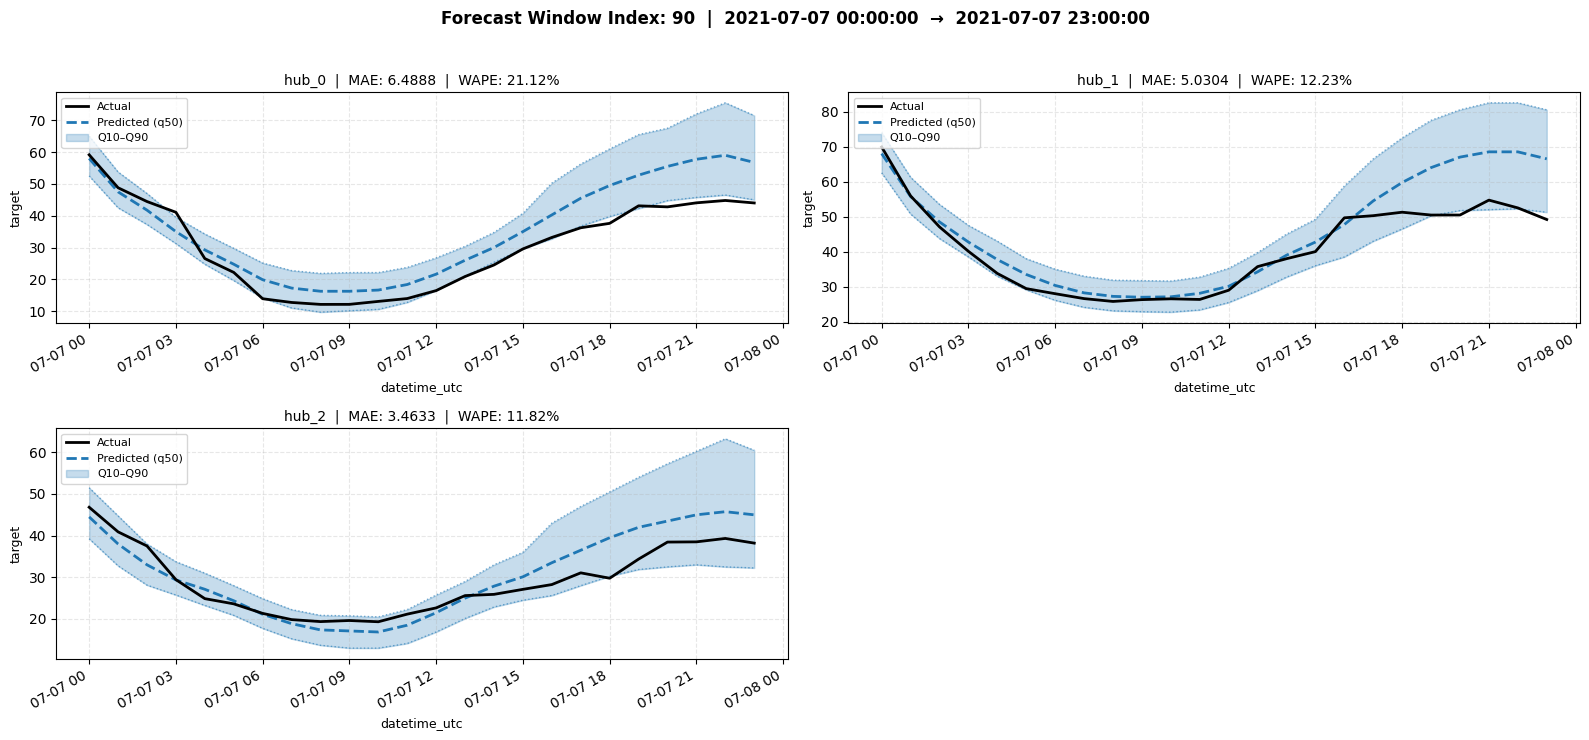

Saved: forecast_test_window_130.png


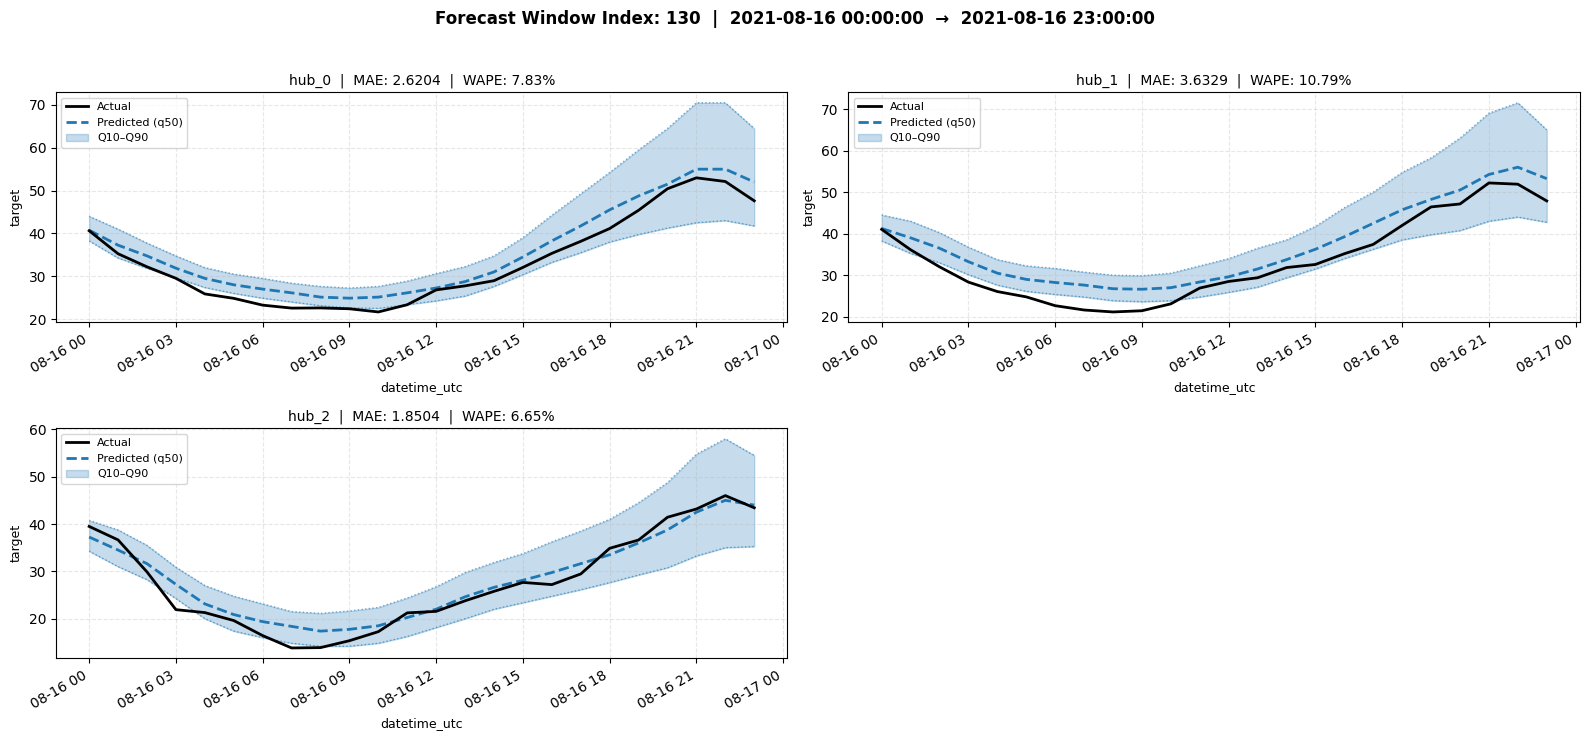

Saved: forecast_test_window_136.png


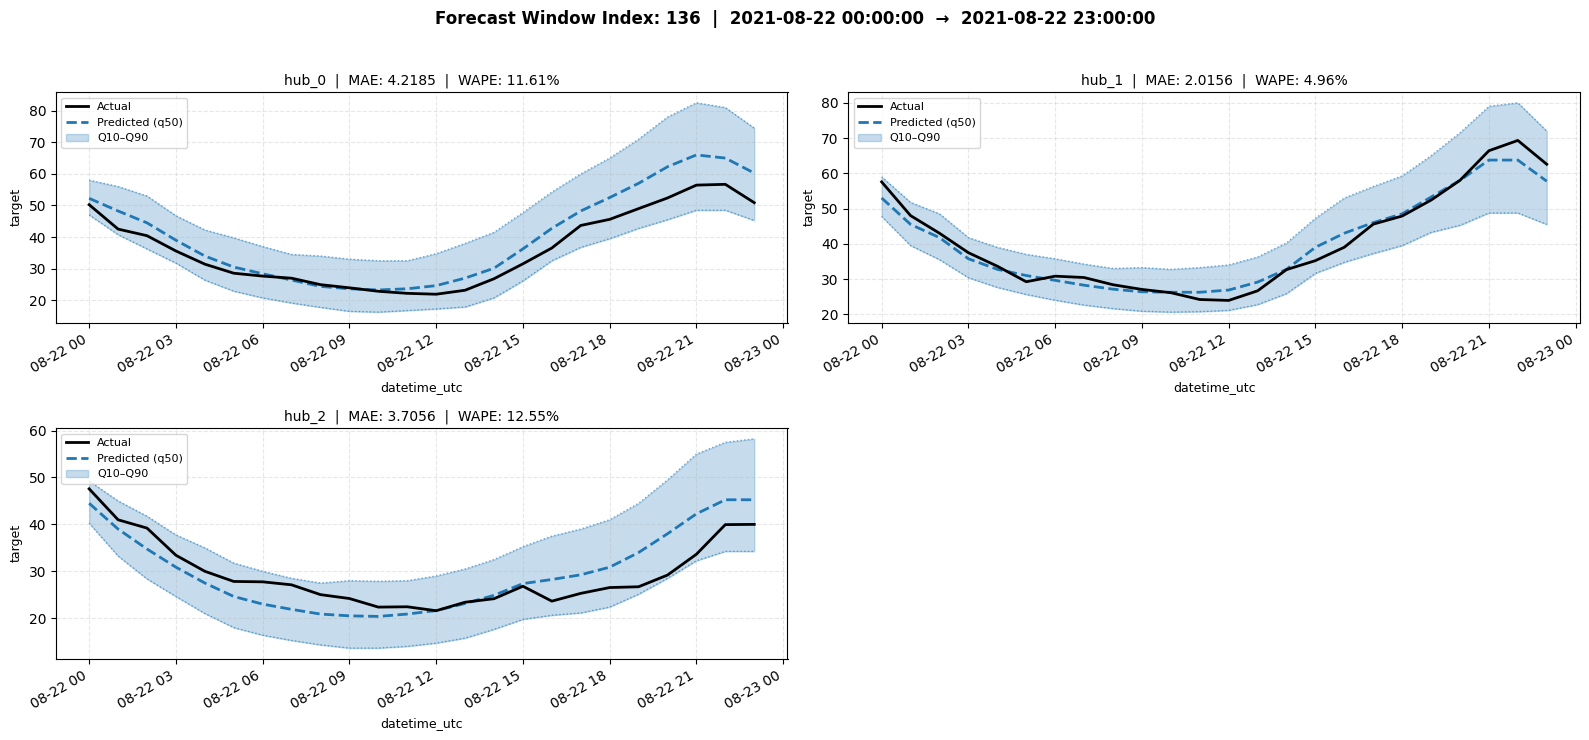

In [21]:
def plot_sampled_forecast_windows(
    df: pd.DataFrame,
    prediction_length: int = 24,
    n_samples: int = 3,
    hubs_per_row: int = 2,
    figsize_width: int = 16,
    seed: int = 42,
    alpha_quantile: float = 0.25,
    actual_color: str = "black",
    pred_color: str = "#1f77b4",
    grid: bool = True,
    save_prefix: str | None = None,
):
    """
    Randomly samples forecast windows and plots Actual vs. Predicted (with Q10-Q90
    bands) for ALL hubs in each sampled window.
 
    Parameters
    ----------
    df : pd.DataFrame
        Output from run_sliding_window_forecast(). Must contain at minimum:
        ['hub', 'datetime_utc', 'target', 'predictions',
         'q_10', 'q_50', 'q_90', 'MAE', 'WAPE'].
    prediction_length : int
        The evaluation/inference horizon used in run_sliding_window_forecast()
        — i.e. CV_HORIZON (24).
        Used only to reconstruct 'window_id' when that column is absent.
        Defaults to 24.
    n_samples : int
        How many distinct windows to randomly sample.
    hubs_per_row : int
        Number of hub-subplots per row in each figure.
    figsize_width : int
        Width of each figure in inches.
    seed : int
        Random seed for reproducible sampling.
    alpha_quantile : float
        Opacity of the Q10–Q90 shaded band.
    actual_color : str
        Line colour for actual values.
    pred_color : str
        Line colour for predicted values and quantile band.
    grid : bool
        Whether to show a dashed grid.
    save_prefix : str | None
        If provided, each figure is saved as '{save_prefix}_window_{id}.png'.
    """
 
    df = df.copy()
 
    # --- Ensure datetime type ---
    if not pd.api.types.is_datetime64_any_dtype(df["datetime_utc"]):
        df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
 
    # --- Reconstruct window IDs using the evaluation horizon (24h) ---
    if "window_id" not in df.columns:
        df["window_id"] = df.groupby("hub").cumcount() // prediction_length
 
    # --- Sample window IDs ---
    all_window_ids = sorted(df["window_id"].unique())
    n_samples = min(n_samples, len(all_window_ids))
 
    rng = np.random.RandomState(seed)
    sampled_ids = sorted(rng.choice(all_window_ids, size=n_samples, replace=False))
 
    # --- Plot each sampled window ---
    for win_id in sampled_ids:
        win_df = df[df["window_id"] == win_id].copy()
        hubs  = sorted(win_df["hub"].unique())
        n_hubs = len(hubs)
 
        n_cols = min(hubs_per_row, n_hubs)
        n_rows = int(np.ceil(n_hubs / n_cols))
 
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_width, 3.5 * n_rows + 0.5),
            sharex=False, sharey=False, squeeze=False,
        )
        axes = axes.flatten()
 
        t_min = win_df["datetime_utc"].min()
        t_max = win_df["datetime_utc"].max()
 
        for ax_idx, hub in enumerate(hubs):
            ax       = axes[ax_idx]
            hub_win = win_df[win_df["hub"] == hub].sort_values("datetime_utc")
 
            if len(hub_win) == 0:
                ax.set_visible(False)
                continue
 
            mae      = hub_win["MAE"].iloc[0]
            wape     = hub_win["WAPE"].iloc[0]
            wape_str = f"{wape:.2%}" if pd.notna(wape) else "N/A"
 
            # Actuals
            ax.plot(
                hub_win["datetime_utc"], hub_win["target"],
                color=actual_color, lw=2, label="Actual", zorder=5,
            )
            # Median prediction
            ax.plot(
                hub_win["datetime_utc"], hub_win["predictions"],
                color=pred_color, lw=2, ls="--", label="Predicted (q50)", zorder=4,
            )
            # Quantile band
            ax.fill_between(
                hub_win["datetime_utc"],
                hub_win["q_10"], hub_win["q_90"],
                color=pred_color, alpha=alpha_quantile, label="Q10–Q90", zorder=1,
            )
            # Quantile boundary lines
            for q_col in ("q_10", "q_90"):
                ax.plot(
                    hub_win["datetime_utc"], hub_win[q_col],
                    color=pred_color, lw=1, ls=":", alpha=0.6, zorder=2,
                )
 
            ax.set_title(
                f"hub_{hub}  |  MAE: {mae:.4f}  |  WAPE: {wape_str}",
                fontsize=10,
            )
            ax.set_xlabel("datetime_utc", fontsize=9)
            ax.set_ylabel("target",   fontsize=9)
            ax.legend(loc="upper left",   fontsize=8)
 
            if grid:
                ax.grid(True, alpha=0.3, linestyle="--")
 
            for label in ax.get_xticklabels():
                label.set_rotation(30)
                label.set_horizontalalignment("right")
 
        for ax_idx in range(n_hubs, len(axes)):
            axes[ax_idx].set_visible(False)
 
        fig.suptitle(
            f"Forecast Window Index: {win_id}  |  {t_min}  →  {t_max}",
            fontsize=12, fontweight="bold", y=0.98,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
 
        if save_prefix:
            fname = f"{save_prefix}_window_{win_id}.png"
            fig.savefig(fname, dpi=150, bbox_inches="tight")
            print(f"Saved: {fname}")
 
        plt.show()


plot_sampled_forecast_windows(
    df                = final_predictions_df,
    prediction_length = EVAL_HORIZON,
    n_samples         = 3,
    hubs_per_row     = 2,
    seed              = 421,
    save_prefix       = "forecast_test",
)